In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

from src.preprocessing import clean_data
from src.feature_engineering import create_features
from src.train_models import train_models
from src.evaluate_models import evaluate_models

In [4]:
df = pd.read_excel("../data/raw/credit_card.xlsx")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Trans_Ct,Avg_Utilization_Ratio,Quarter,Year,Date_Leave
0,712672083,Existing Customer,65,F,0,High School,Married,Less than $40K,Blue,36,...,3,2,1438.3,747,691.3,24,0.519,none,2018,"none,2018"
1,713049933,Existing Customer,47,F,1,Graduate,Married,$40K - $60K,Silver,36,...,2,2,5756.0,0,5756.0,44,0.000,none,2018,"none,2018"
2,713049933,Existing Customer,48,F,1,Graduate,Married,$40K - $60K,Silver,48,...,6,2,5756.0,990,5756.0,25,0.170,none,2019,"none,2019"
3,713135883,Existing Customer,65,F,0,College,Married,Less than $40K,Blue,65,...,5,0,4315.0,393,3598.0,73,0.090,none,2019,"none,2019"
4,713135883,Existing Customer,64,F,0,College,Married,Less than $40K,Blue,53,...,3,0,4315.0,717,3598.0,51,0.166,none,2018,"none,2018"


In [5]:
# Case 1: original target exists
if "Attrition_Flag" in df.columns:
    y = df["Attrition_Flag"]

    # Convert to numeric if needed
    if y.dtype == "object":
        y = y.map({
            "Existing Customer": 0,
            "Attrited Customer": 1
        })

    X = df.drop("Attrition_Flag", axis=1)

# Case 2: encoded target exists
elif "Attrition_Flag_Existing Customer" in df.columns:
    y = 1 - df["Attrition_Flag_Existing Customer"]
    X = df.drop("Attrition_Flag_Existing Customer", axis=1)

else:
    raise ValueError("Target column not found!")

In [6]:
X = pd.get_dummies(X, drop_first=True)

In [7]:
models = train_models(X, y)

model = models["random_forest"]

In [13]:
# Convert everything to numeric safely
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

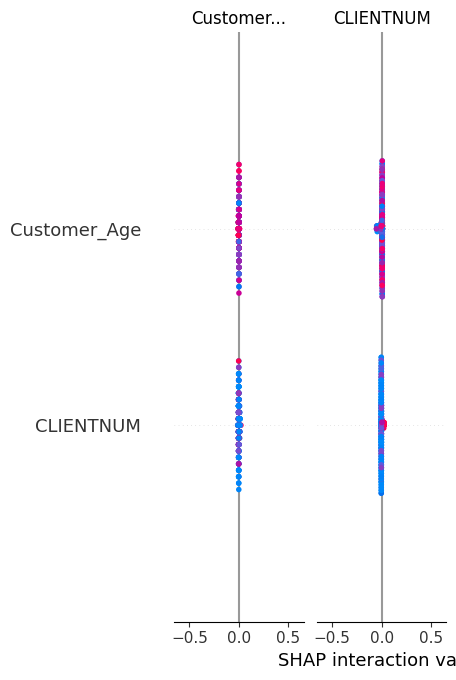

In [16]:
import shap
import numpy as np

# 🔥 Convert EVERYTHING to float safely
X_clean = X.copy()

# Force conversion
X_clean = X_clean.astype(str)           # step 1: unify type
X_clean = X_clean.apply(pd.to_numeric, errors='coerce')  # step 2: convert

# Replace NaNs
X_clean = X_clean.fillna(0)

# 🔥 FINAL: force numeric array
X_clean = X_clean.astype(float)

# Optional: sample for speed
X_sample = X_clean.sample(n=min(300, len(X_clean)), random_state=42)

# SHAP (tree model)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Plot
shap.summary_plot(shap_values, X_sample)